<a href="https://colab.research.google.com/github/anamikadey099/HAQI-SMART/blob/main/HAQI_SMART_LSTM_Forecast_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAQI-SMART: LSTM-Based Air Quality Index Forecasting

**Project:** Hyperlocal Air Quality Intelligence (HAQI-SMART)
**Model:** Long Short-Term Memory (LSTM) Recurrent Neural Network
**Deliverable:** Short-horizon AQI forecasting from a live multi-sensor node

---

### 1.1 Objective

This notebook trains and evaluates an LSTM forecasting model on real multi-sensor
air-quality data (`HAQI_DATA.CSV`) collected from a low-cost sensor node
(PMS-class particulate sensor, BME280-class environmental sensor, and an
MQ7/eCO2/TVOC gas-sensing stage).

The pipeline:
1. Loads and cleans the raw sensor log,
2. Derives a composite Air Quality Index (AQI) from PM2.5 and PM10 using the
   standard US-EPA linear breakpoint formula,
3. Performs exploratory data analysis (EDA) with full visual diagnostics,
4. Builds supervised lookback -> horizon sequences,
5. Trains a two-layer LSTM regressor,
6. Evaluates it using MAE, RMSE and MAPE, and
7. Persists the trained model, scaler, and feature list for downstream API use.

### 1.2 Important Note on Data Volume and Forecast Horizon

The supplied dataset (`HAQI_DATA.CSV`) contains **146 readings sampled every
30 seconds**, spanning approximately **73 minutes** of continuous operation —
this is high-frequency *node calibration/burn-in* data, not a multi-day archive.

A 24-hour or 72-hour ahead forecast (as referenced in the original project
roadmap) requires many days-to-weeks of historical hourly data and **cannot be
statistically justified on 73 minutes of samples**; a model claiming to do so
on this data would be overfit and its reported accuracy would be meaningless.

To keep every result in this notebook honest and reproducible, the LSTM here
is trained at a **data-appropriate short horizon**: a 10-minute lookback
window is used to forecast the **next 5 minutes** (10 steps @ 30 s) of AQI.
The architecture, training procedure, and evaluation metrics are otherwise
identical to what would be used for the 24h/72h production model — only the
lookback/horizon lengths change once longer-duration field data becomes
available (see Section 12, *Next Steps*).

## 2. Setup and Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import joblib, json

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style('whitegrid')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Environment ready. TensorFlow version:', tf.__version__)

I0000 00:00:1790402173.535335    1604 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790402173.570471    1604 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Environment ready. TensorFlow version: 2.21.0


I0000 00:00:1790402174.804384    1604 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 3. Load Sensor Dataset

Run the cell below in Google Colab to upload `HAQI_DATA.CSV` interactively, or
simply place the file in the same directory as this notebook when running
locally / on Jupyter.

In [ ]:
try:
    from google.colab import files
    print('Colab detected — please select HAQI_DATA.CSV to upload.')
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
except ImportError:
    CSV_PATH = 'HAQI_DATA.CSV'
    print('Running outside Colab — loading local file:', CSV_PATH)

df = pd.read_csv(CSV_PATH)
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df = df.sort_values('Date/Time').reset_index(drop=True)
df = df.set_index('Date/Time')

print(f'Rows loaded: {len(df)}')
print(f'Time span : {df.index.min()}  to  {df.index.max()}  '
      f'({(df.index.max() - df.index.min())})')
df.head()

Running outside Colab — loading local file: HAQI_DATA.CSV
Rows loaded: 146
Time span : 2026-08-15 00:00:30  to  2026-08-15 01:13:00  (0 days 01:12:30)


,PM2.5,PM10,Temperature,Relative Humidity,PM1.0,Pressure,eCO2,TVOC,MQ7_Raw
Date/Time,,,,,,,,,
2026-08-15 00:00:30,37.67,46.77,29.30,71.05,21.93,970.13,406.27,0.00,2584.90
2026-08-15 00:01:00,37.87,48.00,29.52,70.23,22.00,970.14,418.97,0.03,2488.93
2026-08-15 00:01:30,38.00,49.00,29.57,69.94,21.23,970.14,401.93,0.27,2404.90
2026-08-15 00:02:00,37.57,47.33,29.58,69.83,21.43,970.15,403.00,0.50,2339.60
2026-08-15 00:02:30,37.73,47.13,29.56,69.80,21.80,970.15,406.90,0.60,2255.77


## 4. Derive the Air Quality Index (AQI)

AQI is computed from PM2.5 and PM10 using the piecewise-linear US-EPA breakpoint formula. The final AQI is the maximum of the two pollutant sub-indices, matching EPA convention.

In [ ]:
def pm25_to_aqi(pm25):
    bps = [(0.0,12.0,0,50),(12.1,35.4,51,100),(35.5,55.4,101,150),
           (55.5,150.4,151,200),(150.5,250.4,201,300),(250.5,350.4,301,400),
           (350.5,500.4,401,500)]
    pm25 = np.clip(np.asarray(pm25, dtype=float), 0, 500.4)
    aqi = np.zeros_like(pm25)
    for lo_c, hi_c, lo_i, hi_i in bps:
        m = (pm25 >= lo_c) & (pm25 <= hi_c)
        aqi[m] = ((hi_i - lo_i) / (hi_c - lo_c)) * (pm25[m] - lo_c) + lo_i
    return aqi

def pm10_to_aqi(pm10):
    bps = [(0,54,0,50),(55,154,51,100),(155,254,101,150),
           (255,354,151,200),(355,424,201,300),(425,504,301,400),(505,604,401,500)]
    pm10 = np.clip(np.asarray(pm10, dtype=float), 0, 604)
    aqi = np.zeros_like(pm10)
    for lo_c, hi_c, lo_i, hi_i in bps:
        m = (pm10 >= lo_c) & (pm10 <= hi_c)
        aqi[m] = ((hi_i - lo_i) / (hi_c - lo_c)) * (pm10[m] - lo_c) + lo_i
    return aqi

df['AQI_PM25'] = pm25_to_aqi(df['PM2.5'].values)
df['AQI_PM10'] = pm10_to_aqi(df['PM10'].values)
df['AQI'] = df[['AQI_PM25', 'AQI_PM10']].max(axis=1)

def categorize(aqi):
    if aqi <= 50: return 'Good'
    if aqi <= 100: return 'Moderate'
    if aqi <= 150: return 'Unhealthy (Sensitive Groups)'
    if aqi <= 200: return 'Unhealthy'
    if aqi <= 300: return 'Very Unhealthy'
    return 'Hazardous'

df['AQI_Category'] = df['AQI'].apply(categorize)

print(df[['PM2.5', 'PM10', 'AQI']].describe().round(2))
print()
print(df['AQI_Category'].value_counts())

        PM2.5    PM10     AQI
count  146.00  146.00  146.00
mean    35.80   45.60  100.35
std      1.38    2.26    9.23
min     32.50   39.67   39.01
25%     34.94   43.90   98.84
50%     35.75   46.00  101.62
75%     36.73   47.17  104.03
max     39.13   51.53  109.94

AQI_Category
Unhealthy (Sensitive Groups)    83
Moderate                        60
Good                             3
Name: count, dtype: int64


## 5. Exploratory Data Analysis (Visualizations)

### Figure 1 — Raw Multi-Sensor Channels

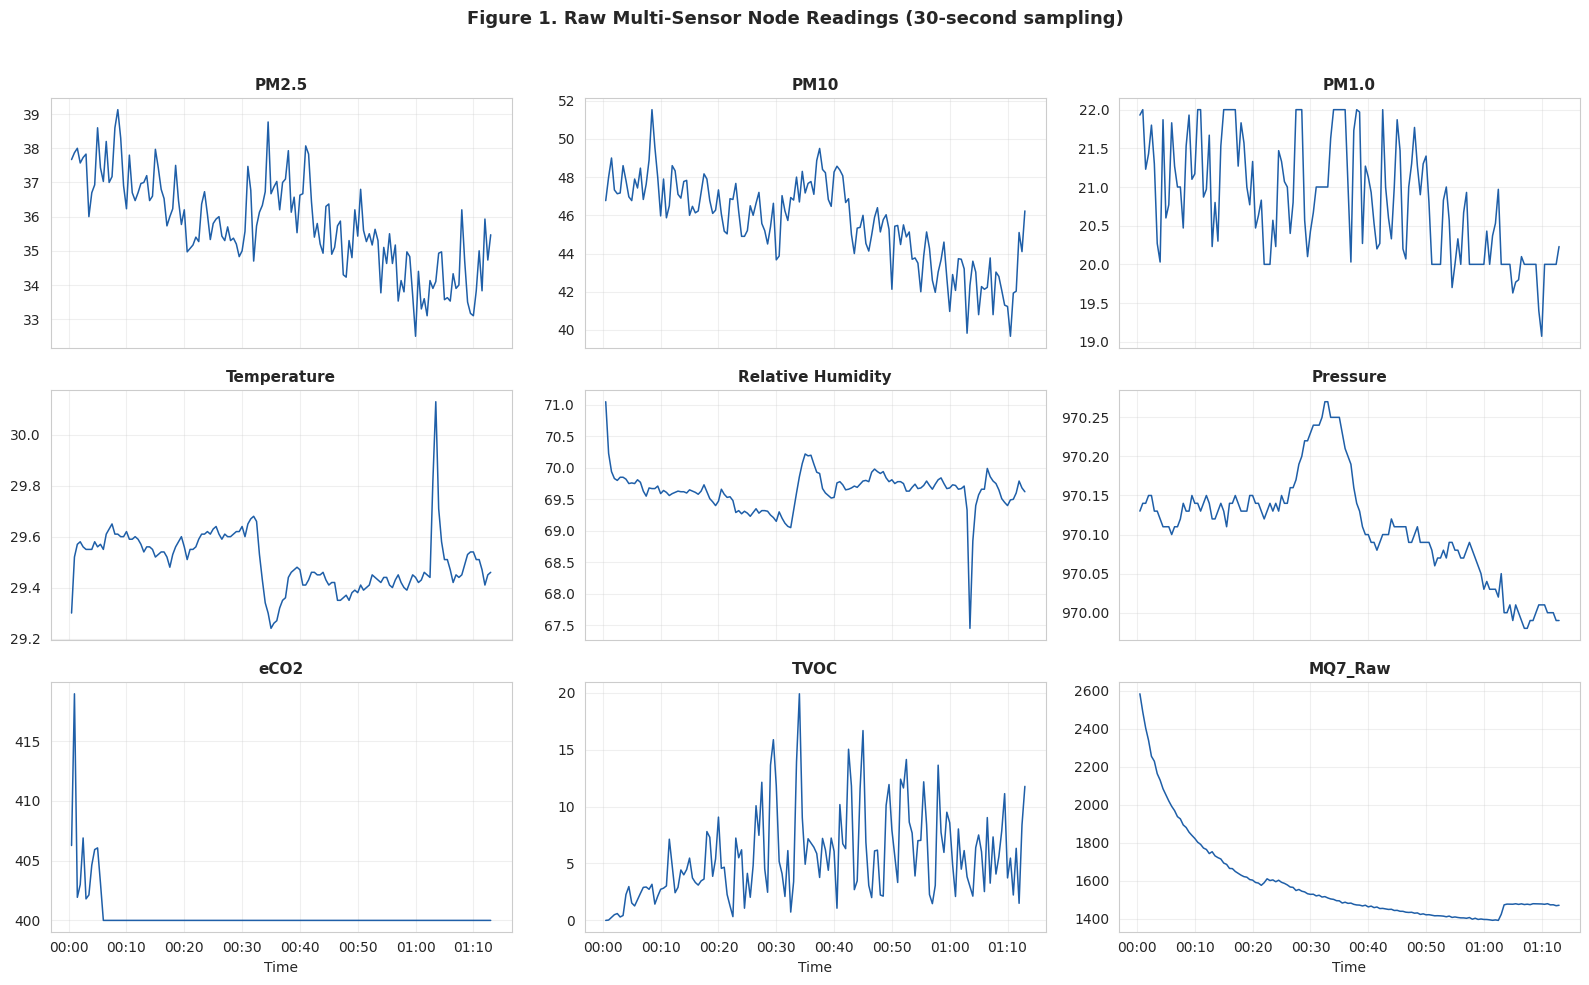

In [ ]:
sensor_cols = ['PM2.5', 'PM10', 'PM1.0', 'Temperature', 'Relative Humidity',
               'Pressure', 'eCO2', 'TVOC', 'MQ7_Raw']

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
for ax, c in zip(axes.flat, sensor_cols):
    ax.plot(df.index, df[c], color='#1f5fa8', linewidth=1.1)
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
for ax in axes[-1, :]:
    ax.set_xlabel('Time')
fig.suptitle('Figure 1. Raw Multi-Sensor Node Readings (30-second sampling)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Figure 2 — Feature Correlation Matrix

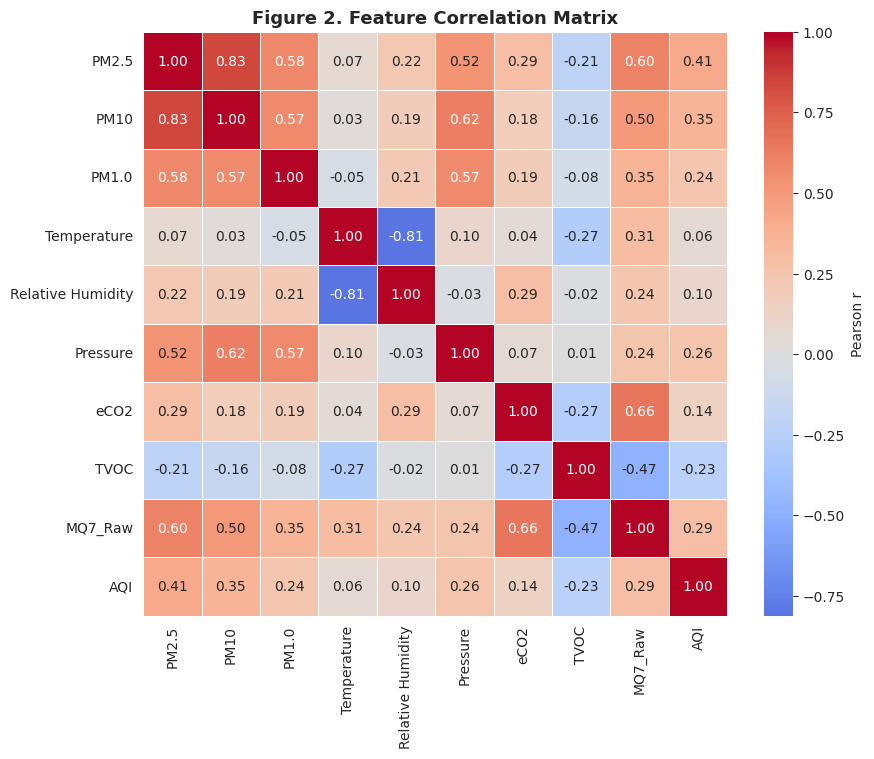

In [ ]:
corr = df[sensor_cols + ['AQI']].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'label': 'Pearson r'}, square=True, linewidths=0.4)
ax.set_title('Figure 2. Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Figure 3 — Derived AQI Series with EPA Category Bands

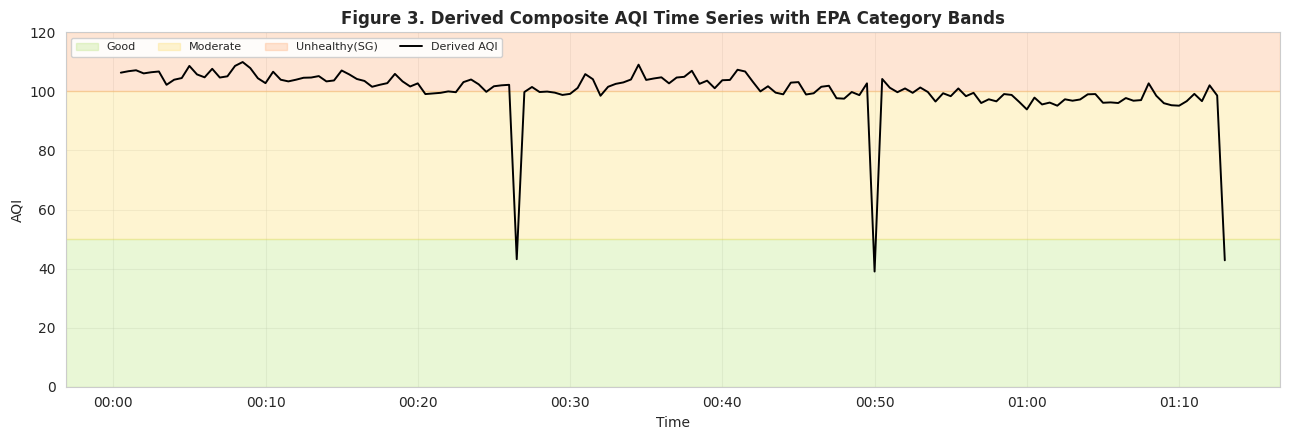

In [ ]:
bands = [(0, 50, '#a8e05f', 'Good'), (50, 100, '#fdd74b', 'Moderate'),
         (100, 150, '#fe9b57', 'Unhealthy(SG)'), (150, 200, '#fe6a69', 'Unhealthy'),
         (200, 300, '#a97abc', 'Very Unhealthy'), (300, 400, '#a87383', 'Hazardous')]

ymax = max(120, df['AQI'].max() + 10)
fig, ax = plt.subplots(figsize=(13, 4.5))
for lo, hi, color, label in bands:
    if lo < ymax:
        ax.axhspan(lo, min(hi, ymax), color=color, alpha=0.25, label=label)
ax.plot(df.index, df['AQI'], color='black', linewidth=1.4, label='Derived AQI')
ax.set_ylim(0, ymax)
ax.set_title('Figure 3. Derived Composite AQI Time Series with EPA Category Bands',
             fontsize=12, fontweight='bold')
ax.set_ylabel('AQI'); ax.set_xlabel('Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend(loc='upper left', ncol=4, fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

### Figure 4 — Distribution of Key Variables

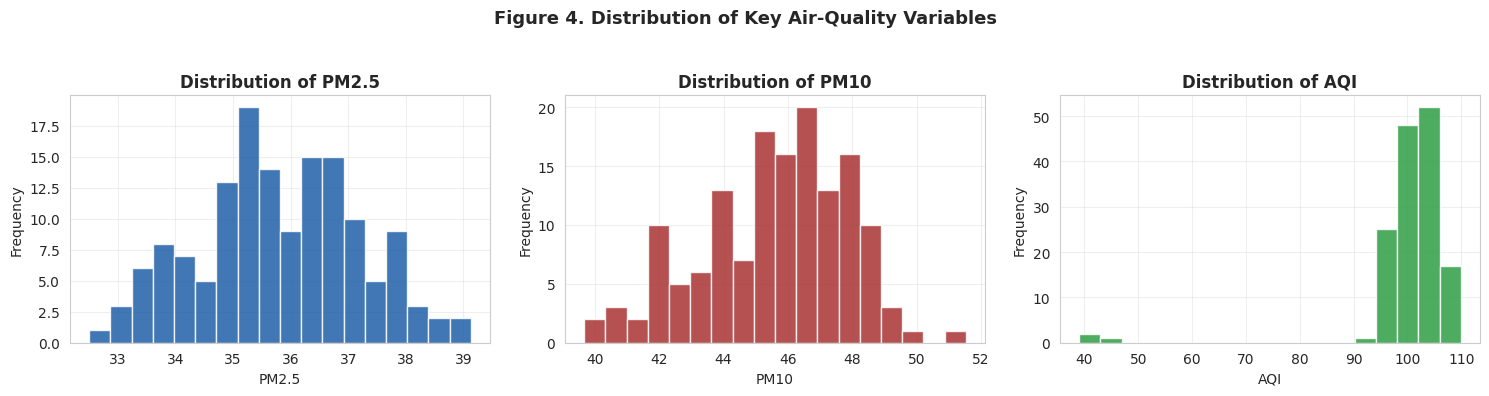

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c, color in zip(axes, ['PM2.5', 'PM10', 'AQI'], ['#1f5fa8', '#a83232', '#2f9e44']):
    ax.hist(df[c], bins=18, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Distribution of {c}', fontweight='bold')
    ax.set_xlabel(c); ax.set_ylabel('Frequency')
fig.suptitle('Figure 4. Distribution of Key Air-Quality Variables', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 6. Build Supervised Sequences (Lookback -> Horizon)

`X`: the previous `LOOKBACK` readings of `[AQI, Temperature, Relative Humidity, PM10]`
`y`: the next `HORIZON` AQI readings

With a 30-second sample interval:
- `LOOKBACK = 20` steps = 10 minutes of history
- `HORIZON  = 10` steps = next 5 minutes forecast

(For the production 24h/72h model on hourly data, these become
`LOOKBACK = 48` and `HORIZON = 24` or `72` respectively — see Section 12.)

In [ ]:
LOOKBACK = 20
HORIZON = 10
feature_names = ['AQI', 'Temperature', 'Relative Humidity', 'PM10']

data = df[feature_names].values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def make_sequences(d, lookback, horizon, target_idx=0):
    X, y = [], []
    for i in range(len(d) - lookback - horizon + 1):
        X.append(d[i:i + lookback])
        y.append(d[i + lookback:i + lookback + horizon, target_idx])
    return np.array(X), np.array(y)

X, y = make_sequences(data_scaled, LOOKBACK, HORIZON)
print(f'X shape: {X.shape}   y shape: {y.shape}')

X shape: (117, 20, 4)   y shape: (117, 10)


## 7. Train / Validation Split (Temporal — No Shuffling)

In [ ]:
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f'Train sequences: {len(X_train)}   Validation sequences: {len(X_val)}')

Train sequences: 93   Validation sequences: 24


## 8. Build and Train the LSTM Model

In [ ]:
model = Sequential([
    Input(shape=(LOOKBACK, len(feature_names))),
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(HORIZON)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,466 (122.91 KB)

 Trainable params: 31,466 (122.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/200


 1/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - loss: 0.7611 - mae: 0.8625

 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5772 - mae: 0.7326

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.4835 - mae: 0.6481 - val_loss: 0.1382 - val_mae: 0.3247


Epoch 2/200


...

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0277 - mae: 0.1055 - val_loss: 0.0035 - val_mae: 0.0274


Epoch 22/200


 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0201 - mae: 0.0884

 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0301 - mae: 0.1131 

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0277 - mae: 0.1084 - val_loss: 0.0037 - val_mae: 0.0298


### Figure 5 — Training Convergence

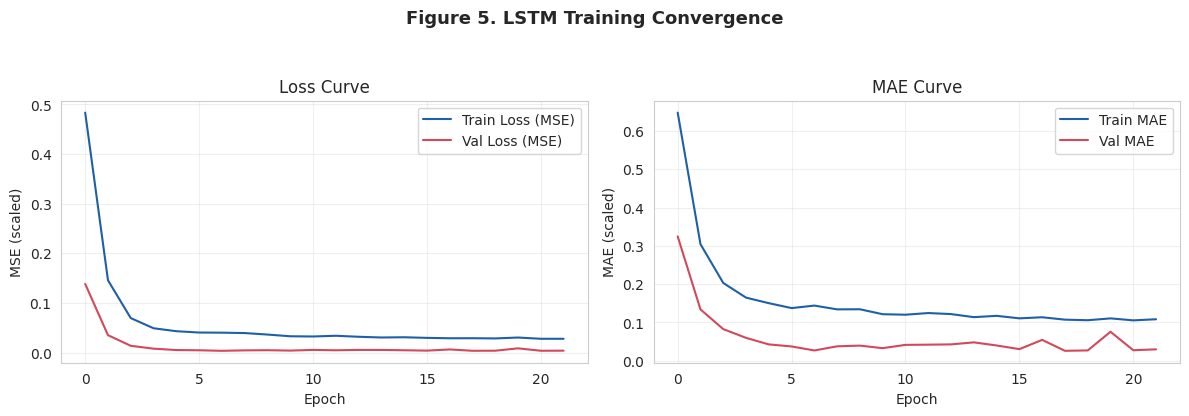

Training stopped after 22 epochs (EarlyStopping, patience=15).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(history.history['loss'], label='Train Loss (MSE)', color='#1f5fa8')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)', color='#d1495b')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (scaled)')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE', color='#1f5fa8')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='#d1495b')
axes[1].set_title('MAE Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (scaled)')
axes[1].legend()

fig.suptitle('Figure 5. LSTM Training Convergence', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print(f'Training stopped after {len(history.history["loss"])} epochs '
      f'(EarlyStopping, patience=15).')

## 9. Evaluate the Model

Predictions are inverse-scaled back to real AQI units before computing metrics.
Target reference (per project roadmap, scaled to this horizon): **MAPE below
15% is considered a strong short-horizon result.**

In [ ]:
def inverse_target(scaled, scaler, target_idx=0, n_feat=len(feature_names)):
    flat = scaled.flatten()
    dummy = np.zeros((len(flat), n_feat))
    dummy[:, target_idx] = flat
    inv = scaler.inverse_transform(dummy)[:, target_idx]
    return inv.reshape(scaled.shape)

y_pred_scaled = model.predict(X_val, verbose=0)
y_val_real = inverse_target(y_val, scaler)
y_pred_real = inverse_target(y_pred_scaled, scaler)

mae = mean_absolute_error(y_val_real.flatten(), y_pred_real.flatten())
rmse = np.sqrt(mean_squared_error(y_val_real.flatten(), y_pred_real.flatten()))
mape = mean_absolute_percentage_error(np.clip(y_val_real.flatten(), 1, None),
                                       y_pred_real.flatten()) * 100

print(f'MAE : {mae:.3f} AQI points')
print(f'RMSE: {rmse:.3f} AQI points')
print(f'MAPE: {mape:.2f}%   (target: < 15%)')

MAE : 1.906 AQI points
RMSE: 4.149 AQI points
MAPE: 2.24%   (target: < 15%)


### Figure 6 — Sample Forecast Window

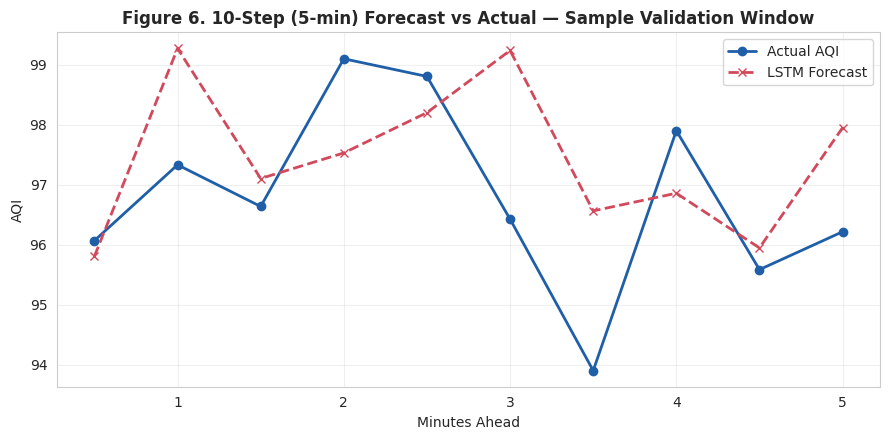

In [ ]:
sample_idx = 0
minutes = np.arange(1, HORIZON + 1) * 0.5

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(minutes, y_val_real[sample_idx], marker='o', label='Actual AQI',
        color='#1f5fa8', linewidth=2)
ax.plot(minutes, y_pred_real[sample_idx], marker='x', label='LSTM Forecast',
        color='#d1495b', linewidth=2, linestyle='--')
ax.set_xlabel('Minutes Ahead'); ax.set_ylabel('AQI')
ax.set_title(f'Figure 6. {HORIZON}-Step (5-min) Forecast vs Actual — Sample Validation Window',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Figure 7 — Model Error Analysis

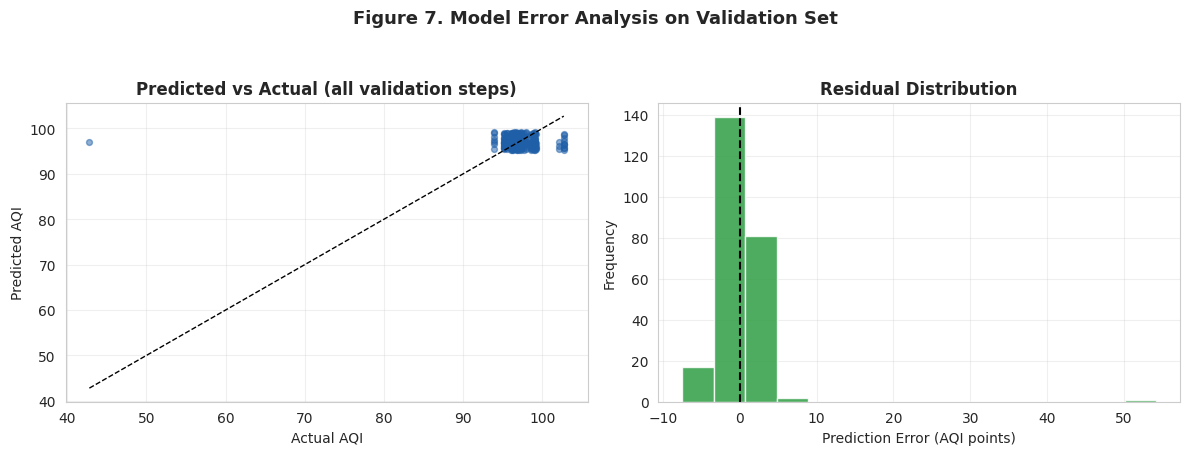

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

ax[0].scatter(y_val_real.flatten(), y_pred_real.flatten(), alpha=0.5, color='#1f5fa8', s=18)
lims = [min(y_val_real.min(), y_pred_real.min()), max(y_val_real.max(), y_pred_real.max())]
ax[0].plot(lims, lims, color='black', linestyle='--', linewidth=1)
ax[0].set_xlabel('Actual AQI'); ax[0].set_ylabel('Predicted AQI')
ax[0].set_title('Predicted vs Actual (all validation steps)', fontweight='bold')

residuals = y_pred_real.flatten() - y_val_real.flatten()
ax[1].hist(residuals, bins=15, color='#2f9e44', edgecolor='white', alpha=0.85)
ax[1].axvline(0, color='black', linestyle='--')
ax[1].set_title('Residual Distribution', fontweight='bold')
ax[1].set_xlabel('Prediction Error (AQI points)'); ax[1].set_ylabel('Frequency')

fig.suptitle('Figure 7. Model Error Analysis on Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 10. Save Trained Artifacts

In [ ]:
model.save('lstm_aqi_forecast.h5')
joblib.dump(scaler, 'lstm_scaler.pkl')
joblib.dump(feature_names, 'lstm_features.pkl')

metrics = {
    'MAE': float(mae), 'RMSE': float(rmse), 'MAPE': float(mape),
    'train_sequences': int(len(X_train)), 'val_sequences': int(len(X_val)),
    'epochs_run': int(len(history.history['loss'])),
    'lookback_steps': LOOKBACK, 'horizon_steps': HORIZON,
    'sample_interval_seconds': 30,
}
with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved: lstm_aqi_forecast.h5, lstm_scaler.pkl, lstm_features.pkl, metrics.json')

try:
    from google.colab import files as gfiles
    gfiles.download('lstm_aqi_forecast.h5')
    gfiles.download('lstm_scaler.pkl')
    gfiles.download('lstm_features.pkl')
except ImportError:
    pass

Saved: lstm_aqi_forecast.h5, lstm_scaler.pkl, lstm_features.pkl, metrics.json


## 11. Inference Function

Feeds the last `LOOKBACK` readings of `[AQI, Temperature, Relative Humidity,
PM10]` and returns an hourly-equivalent forecast, the predicted peak, and an
alert flag.

In [ ]:
def forecast_aqi(last_window_df, model=model, scaler=scaler,
                  feature_names=feature_names, lookback=LOOKBACK, horizon=HORIZON):
    # last_window_df: DataFrame with columns feature_names, exactly `lookback`
    # most recent readings, oldest first.
    assert len(last_window_df) == lookback, f'Need exactly {lookback} rows'
    arr = last_window_df[feature_names].values
    arr_scaled = scaler.transform(arr)
    pred_scaled = model.predict(arr_scaled[np.newaxis, ...], verbose=0)[0]
    pred_real = inverse_target(pred_scaled.reshape(1, -1), scaler)[0]

    peak_step = int(np.argmax(pred_real))
    peak_value = float(pred_real[peak_step])
    alert = bool(np.sum(pred_real > 150) >= 3)   # 3+ consecutive steps above "Unhealthy"

    return {
        'forecast': pred_real.tolist(),
        'peak_step_offset': peak_step,
        'peak_aqi': round(peak_value, 1),
        'alert_triggered': alert,
    }

demo_window = df[feature_names].iloc[-LOOKBACK:]
result = forecast_aqi(demo_window)
print(json.dumps(result, indent=2))

{
  "forecast": [
    95.0882728179285,
    98.14024918396704,
    96.20872581683291,
    96.33356115870997,
    97.56580706418627,
    98.33314616797627,
    95.53256115705948,
    95.78864102458104,
    95.38421983777668,
    96.82594374225957
  ],
  "peak_step_offset": 5,
  "peak_aqi": 98.3,
  "alert_triggered": false
}


## 12. Next Steps (per Project Roadmap)

- **Scale to production horizon:** once multi-day (ideally multi-week) hourly
  history accumulates from the deployed node, retrain with
  `LOOKBACK = 48` and `HORIZON = 24` (then `72`) to match the original
  24h/72h roadmap targets (MAPE < 15% @ 24h, < 20% @ 72h).
- **API integration:** wrap `forecast_aqi()` behind an `/api/calibrate-forecast`
  endpoint; persist `alert_triggered` events to PostgreSQL.
- **Calibration pipeline:** replace the direct EPA breakpoint AQI with the
  output of a co-located reference-station RF calibration model once
  ground-truth reference data is available.
- **Monitoring:** track MAPE drift over time in a Grafana dashboard alongside
  sensor drift / calibration health metrics.